# M07 · Taller integrador: reconocer actividad humana con tensores

**Pregunta central:** ¿podemos distinguir la actividad que realiza una persona
usando únicamente operaciones tensoriales en PyTorch?

En este taller construiremos un reconocedor por prototipos. No utilizaremos
redes neuronales, `autograd` ni clasificadores de otra biblioteca. Toda la
solución se obtendrá combinando:

- permutación de ejes;
- reducciones;
- broadcasting;
- producto de Hadamard;
- producto exterior;
- producto matricial;
- una transformación afín final.

El objetivo no es conseguir la mayor exactitud posible. El objetivo es poder
explicar **qué significa cada eje, qué índice desaparece y por qué la forma
resultante es correcta**.



## El problema y los datos reales

Utilizaremos un subconjunto de **Human Activity Recognition Using
Smartphones**, publicado por UCI Machine Learning Repository. Treinta personas
realizaron seis actividades llevando un teléfono en la cintura. El
acelerómetro y el giroscopio registraron señales a 50 Hz, posteriormente
separadas en ventanas de 128 mediciones.

Actividades:

1. caminar;
2. subir escaleras;
3. bajar escaleras;
4. estar sentado;
5. estar de pie;
6. estar acostado.

Fuente: <https://archive.ics.uci.edu/dataset/240/humanactivityrecognitionusingsmartphones>

DOI: `10.24432/C54S4K` · Licencia indicada por UCI: CC BY 4.0.

**Dependencias:** este notebook utiliza PyTorch, NumPy, IPython.
Todas están declaradas en el entorno estudiantil actualizado y se instalan con
`uv sync --frozen`.



## La ruta completa antes del código

<svg viewBox="0 0 1180 250" xmlns="http://www.w3.org/2000/svg" role="img" aria-label="Flujo del taller desde señales hasta predicciones">
  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto"><path d="M0,0 L0,6 L9,3 z" fill="#667085"/></marker>
  </defs>
  <rect x="20" y="65" width="170" height="110" rx="14" fill="#ede9fe" stroke="#6d4aff" stroke-width="3"/>
  <text x="105" y="104" text-anchor="middle" font-size="19" font-family="Arial" font-weight="700" fill="#30206f">Señales crudas</text>
  <text x="105" y="137" text-anchor="middle" font-size="18" font-family="Arial" fill="#30206f">(B, C, T)</text>
  <text x="105" y="161" text-anchor="middle" font-size="14" font-family="Arial" fill="#5f548d">canal antes de tiempo</text>
  <line x1="190" y1="120" x2="232" y2="120" stroke="#667085" stroke-width="3" marker-end="url(#arrow)"/>
  <rect x="240" y="65" width="170" height="110" rx="14" fill="#fff2e8" stroke="#ed7125" stroke-width="3"/>
  <text x="325" y="104" text-anchor="middle" font-size="19" font-family="Arial" font-weight="700" fill="#8a3b0d">Permutar</text>
  <text x="325" y="137" text-anchor="middle" font-size="18" font-family="Arial" fill="#8a3b0d">(B, T, C)</text>
  <text x="325" y="161" text-anchor="middle" font-size="14" font-family="Arial" fill="#9b5d39">declarar los ejes</text>
  <line x1="410" y1="120" x2="452" y2="120" stroke="#667085" stroke-width="3" marker-end="url(#arrow)"/>
  <rect x="460" y="65" width="170" height="110" rx="14" fill="#e7f7f3" stroke="#078b75" stroke-width="3"/>
  <text x="545" y="100" text-anchor="middle" font-size="19" font-family="Arial" font-weight="700" fill="#075e51">Centrar y medir</text>
  <text x="545" y="132" text-anchor="middle" font-size="17" font-family="Arial" fill="#075e51">Hadamard</text>
  <text x="545" y="158" text-anchor="middle" font-size="14" font-family="Arial" fill="#427e75">reducción temporal</text>
  <line x1="630" y1="120" x2="672" y2="120" stroke="#667085" stroke-width="3" marker-end="url(#arrow)"/>
  <rect x="680" y="65" width="170" height="110" rx="14" fill="#fff2e8" stroke="#ed7125" stroke-width="3"/>
  <text x="765" y="100" text-anchor="middle" font-size="19" font-family="Arial" font-weight="700" fill="#8a3b0d">Interacciones</text>
  <text x="765" y="132" text-anchor="middle" font-size="17" font-family="Arial" fill="#8a3b0d">productos exteriores</text>
  <text x="765" y="158" text-anchor="middle" font-size="14" font-family="Arial" fill="#9b5d39">(B, C, C)</text>
  <line x1="850" y1="120" x2="892" y2="120" stroke="#667085" stroke-width="3" marker-end="url(#arrow)"/>
  <rect x="900" y="65" width="170" height="110" rx="14" fill="#ede9fe" stroke="#6d4aff" stroke-width="3"/>
  <text x="985" y="100" text-anchor="middle" font-size="19" font-family="Arial" font-weight="700" fill="#30206f">Prototipos</text>
  <text x="985" y="132" text-anchor="middle" font-size="17" font-family="Arial" fill="#30206f">producto matricial</text>
  <text x="985" y="158" text-anchor="middle" font-size="14" font-family="Arial" fill="#5f548d">puntajes por actividad</text>
  <line x1="1070" y1="120" x2="1112" y2="120" stroke="#667085" stroke-width="3" marker-end="url(#arrow)"/>
  <circle cx="1140" cy="120" r="30" fill="#e7f7f3" stroke="#078b75" stroke-width="3"/>
  <text x="1140" y="126" text-anchor="middle" font-size="18" font-family="Arial" font-weight="700" fill="#075e51">ŷ</text>
  <text x="590" y="225" text-anchor="middle" font-size="16" font-family="Arial" fill="#344054">Cada flecha debe conservar una interpretación matemática explícita.</text>
</svg>



In [1]:
from __future__ import annotations

import html
import sys
from pathlib import Path

import matplotlib.pyplot as plt
plt.style.use("default")
import torch
from IPython.display import SVG, display

torch.set_printoptions(precision=4, sci_mode=False)

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Dispositivo utilizado: CPU")



Python: 3.13.13
PyTorch: 2.13.0
Dispositivo utilizado: CPU


## 1. Cargar el conjunto y declarar el contrato de ejes

El archivo conserva la forma en que se apilaron las señales originales:

$$
X_{\text{raw}}\in\mathbb{R}^{B\times C\times T}.
$$

- $B$: ventanas u observaciones;
- $C=9$: canales de señal;
- $T=128$: instantes temporales.

Antes de ejecutar la celda siguiente, prediga las formas de entrenamiento y
prueba.

Un archivo `.pt` es un archivo binario utilizado habitualmente por PyTorch para guardar tensores, parámetros de modelos u otros objetos.

En el taller, `har_subset.pt` no contiene un modelo entrenado. Contiene los datos preparados:
- señales de entrenamiento y prueba;
- etiquetas de las actividades;
- identificadores de participantes;
- nombres de canales y actividades;
- metadatos sobre la fuente.

### Cómo leer una observación

Cada ventana es una observación completa. Para una ventana fija $b$, el objeto
$X_{\text{raw},b}$ contiene una matriz de $9$ canales por $128$ instantes:

$$
X_{\text{raw},b}\in\mathbb{R}^{9\times128}.
$$

Una componente individual se escribe como $X_{\text{raw},bct}$:

- $b$ selecciona una ventana;
- $c$ selecciona uno de los nueve canales;
- $t$ selecciona uno de los 128 instantes.

Por ejemplo, `X_train_raw[0, 2, 10]` es un solo número: la medición del canal
$2$, en el instante $10$, de la primera ventana de entrenamiento.

En entrenamiento existen $720$ ventanas y en prueba existen $360$. Por eso:

$$
X_{\text{train,raw}}\in\mathbb{R}^{720\times9\times128},
\qquad
X_{\text{test,raw}}\in\mathbb{R}^{360\times9\times128}.
$$

Cada ventana tiene además una etiqueta $y_b$ que indica cuál de las seis
actividades se realizaba. Los identificadores de participantes se utilizan
para verificar que ninguna persona aparezca simultáneamente en entrenamiento
y prueba. Esa comprobación no modifica los datos: funciona como una alarma
contra fuga de información.

Los nueve canales no representan nueve sensores físicos: incluyen tres ejes de
aceleración total, tres ejes de velocidad angular y tres ejes de aceleración
corporal calculados durante el procesamiento del conjunto.



In [2]:
candidate_paths = [
    Path.cwd() / "data" / "har_subset.pt",
    Path.cwd().parent / "data" / "har_subset.pt",
    Path.cwd()
    / "modules"
    / "m07-tensores-pytorch"
    / "data"
    / "har_subset.pt",
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    searched = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(
        "No se encontró har_subset.pt. Mantenga las carpetas notebooks/ y data/ "
        f"juntas. Rutas revisadas:\n{searched}"
    )

data = torch.load(data_path, map_location="cpu", weights_only=True)

X_train_raw = data["X_train_raw"]
y_train = data["y_train"]
X_test_raw = data["X_test_raw"]
y_test = data["y_test"]
activity_names = data["activity_names"]
channel_names = data["channel_names"]

print("Archivo:", data_path.resolve())
print("X_train_raw:", tuple(X_train_raw.shape))
print("X_test_raw: ", tuple(X_test_raw.shape))
print("Actividades: ", activity_names)
print("Canales: ", channel_names)

assert tuple(X_train_raw.shape) == (720, 9, 128)
assert tuple(X_test_raw.shape) == (360, 9, 128)
assert not (
    set(data["subject_train"].tolist()) & set(data["subject_test"].tolist())
), "Un participante aparece en entrenamiento y prueba."



Archivo: /Users/rflores/Desktop/USFQ/2026-2027/Primer Smestre/Mate_Progra_IA_master/mate-progra-ml-course/modules/m07-tensores-pytorch/data/har_subset.pt
X_train_raw: (720, 9, 128)
X_test_raw:  (360, 9, 128)
Actividades:  ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
Canales:  ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']


La separación por participantes es importante: si una misma persona apareciera
en entrenamiento y prueba, el resultado podría aprovechar patrones personales
en lugar de generalizar hacia personas nuevas.



### Visualizar dos ventanas con Matplotlib

Si el entorno aún no contiene Matplotlib, se puede agregar desde la carpeta del proyecto con:

```bash
uv add matplotlib
```

Después seleccione nuevamente el kernel de `.venv` o reinicie el kernel activo.



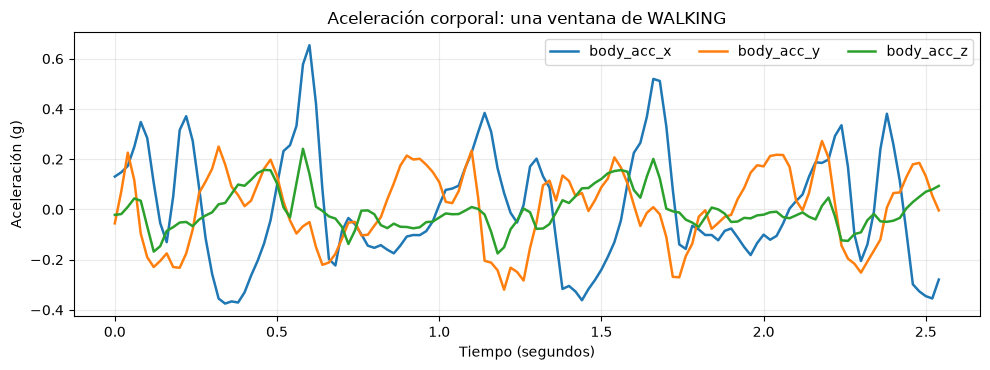

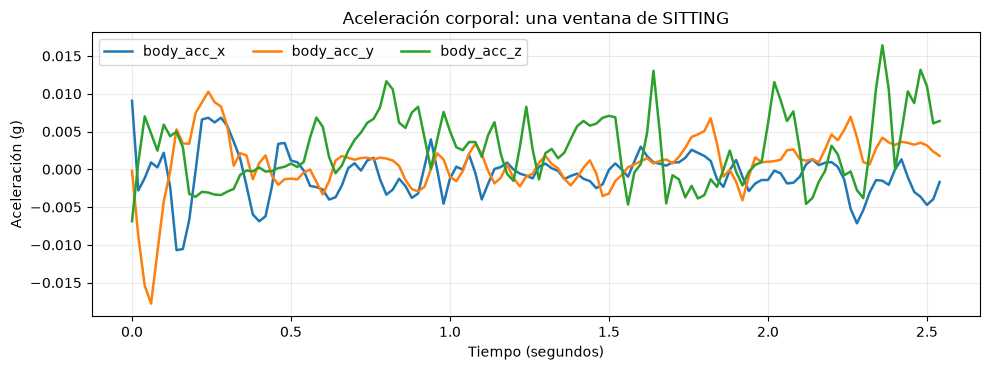

In [3]:
walking_index = int(torch.where(y_test == 0)[0][0])
sitting_index = int(torch.where(y_test == 3)[0][0])
time_seconds = torch.arange(X_test_raw.shape[2]) / 50


def plot_body_acceleration(sample_index: int, activity: str) -> None:
    """Grafica los tres ejes de aceleración corporal de una ventana."""

    figure, axis = plt.subplots(figsize=(10, 3.8))
    for channel_index, channel_name in enumerate(channel_names[:3]):
        axis.plot(
            time_seconds.numpy(),
            X_test_raw[sample_index, channel_index].numpy(),
            label=channel_name,
            linewidth=1.8,
        )
    axis.set(
        title=f"Aceleración corporal: una ventana de {activity}",
        xlabel="Tiempo (segundos)",
        ylabel="Aceleración (g)",
    )
    axis.grid(alpha=0.25)
    axis.legend(ncol=3)
    figure.tight_layout()
    plt.show()

plot_body_acceleration(walking_index, "WALKING")
plot_body_acceleration(sitting_index, "SITTING")



**Lectura del gráfico.** Caminar produce oscilaciones corporales más visibles;
al estar sentado, la aceleración corporal varía menos. Una sola señal no basta
para clasificar todas las actividades, pero sugiere que la intensidad y las
interacciones entre canales contienen información útil.



## 2. Permutar: colocar el tiempo antes de los canales

Queremos trabajar con la convención

$$
X\in\mathbb{R}^{B\times T\times C}.
$$

La operación no modifica los valores: únicamente cambia qué posición ocupa
cada eje.

### Qué cambia realmente

La forma original es $(B,C,T)$: primero se elige la observación, después el
canal y finalmente el instante. Para calcular relaciones entre canales en
cada instante conviene usar $(B,T,C)$, de modo que `X[b, t, :]` sea el vector
con los nueve canales observados simultáneamente.

La correspondencia entre ambas representaciones es:

$$
X_{btc}=X_{\text{raw},bct}.
$$

Por ejemplo, el mismo número se encuentra en dos posiciones diferentes:

```python
X_train_raw[0, 2, 10] == X_train[0, 10, 2]
```

En `permute(0, 2, 1)`, los números indican el nuevo orden de los ejes
originales: se conserva el eje $0$ de observaciones, se coloca el eje $2$ de
tiempo en la segunda posición y el eje $1$ de canales en la tercera.

$$
(720,9,128)\longrightarrow(720,128,9).
$$

Esta operación no es una multiplicación ni cambia las mediciones. Solo cambia
la manera en que interpretamos y recorremos sus ejes.



In [4]:
X_train = X_train_raw.permute(0, 2, 1)
X_test = X_test_raw.permute(0, 2, 1)

print("Antes:", tuple(X_train_raw.shape), "= (observación, canal, tiempo)")
print("Después:", tuple(X_train.shape), "= (observación, tiempo, canal)")

# La misma componente debe localizarse con índices reordenados.
assert X_train_raw[0, 2, 10] == X_train[0, 10, 2]
assert tuple(X_train.shape) == (720, 128, 9)



Antes: (720, 9, 128) = (observación, canal, tiempo)
Después: (720, 128, 9) = (observación, tiempo, canal)


## 3. Reducir sobre tiempo y centrar mediante broadcasting

Para cada observación $b$ y canal $c$, calculamos su media temporal:

$$
\mu_{bc}=\frac{1}{T}\sum_{t=1}^{T}X_{btc}.
$$

El índice $t$ se suma y desaparece; sobreviven $b,c$. Por tanto,
$\mu\in\mathbb{R}^{B\times C}$.

Para restar la media en todos los instantes, reintroducimos un eje unitario:

$$
\widetilde X_{btc}=X_{btc}-\mu_{bc}.
$$

### Qué significa la ecuación

- $X_{btc}$ es la medición original de la ventana $b$, instante $t$ y canal
  $c$.
- $\mu_{bc}$ es la media de ese canal dentro de esa ventana.
- $\widetilde X_{btc}$ es la medición después de restar la media.

Esto permite separar dos tipos de información:
- Nivel promedio: alrededor de qué valor se encuentra la señal.
- Variación temporal: cuánto sube o baja respecto a ese promedio.

La media $\mu_{bc}$ no depende de $t$, porque resume todos los instantes. La
misma media se resta, por tanto, en cada uno de los $128$ instantes del canal.

Supongamos que un canal contiene solamente tres mediciones:

$$
[2,4,6].
$$

Su media es:

$$
\mu=\frac{2+4+6}{3}=4.
$$

Después de centrar:

$$
\widetilde X=[2-4,4-4,6-4]=[-2,0,2].
$$

La señal no desapareció: ahora describe cuánto se separa cada medición de su
nivel promedio.

### Qué significa “reintroducir un eje unitario”

Antes de calcular la media, $X_{\text{train}}$ tiene forma $(720,128,9)$. Al
ejecutar `mean(dim=1)`, se resume el eje temporal y se obtiene:

$$
\mu_{\text{train}}:\;(720,9).
$$

Para indicar que esta media debe aplicarse en todos los instantes, PyTorch la
representa como $(720,1,9)$:

```python
mu_train[:, None, :]
```

El eje de tamaño $1$ ocupa la posición temporal. Mediante broadcasting,
PyTorch lo extiende conceptualmente hasta $128$:

$$
(720,128,9)-(720,1,9)\longrightarrow(720,128,9).
$$

Centrar elimina el nivel medio, pero no cambia la escala de la señal. Después
del proceso, la media temporal de cada canal debe ser aproximadamente cero.



In [5]:
mu_train = X_train.mean(dim=1)
mu_test = X_test.mean(dim=1)

Xc_train = X_train - mu_train[:, None, :]
Xc_test = X_test - mu_test[:, None, :]

print("mu_train:", tuple(mu_train.shape))
print("Xc_train:", tuple(Xc_train.shape))
print("Mayor media temporal residual:", float(Xc_train.mean(dim=1).abs().max()))

assert tuple(mu_train.shape) == (720, 9)
assert tuple(Xc_train.shape) == (720, 128, 9)
assert float(Xc_train.mean(dim=1).abs().max()) < 1e-5



mu_train: (720, 9)
Xc_train: (720, 128, 9)
Mayor media temporal residual: 1.5273690223693848e-07


Centrar no significa “hacer todos los valores pequeños”. Significa quitar a
cada canal su nivel promedio dentro de la ventana para estudiar cómo cambia
alrededor de ese nivel.



## 4. Producto de Hadamard: energía por canal

Multiplicamos cada componente por sí misma:

$$
H_{btc}=\widetilde X_{btc}\widetilde X_{btc}.
$$

Hadamard conserva $b,t,c$. Después reducimos el tiempo:

$$
E_{bc}=\frac{1}{T}\sum_t H_{btc}.
$$

### Cómo interpretar la operación

El producto de Hadamard multiplica componentes que ocupan la misma posición.
Aquí utilizamos el mismo tensor dos veces, por lo que cada valor centrado se
eleva al cuadrado:

$$
H_{btc}=\widetilde X_{btc}^{2}.
$$

No es un producto matricial: no se combinan filas con columnas y ningún índice
desaparece todavía. Por eso la forma se conserva:

$$
(B,T,C)*(B,T,C)\longrightarrow(B,T,C).
$$

Con la señal centrada del ejemplo anterior:

$$
[-2,0,2]*[-2,0,2]=[4,0,4].
$$

Elevar al cuadrado evita que las variaciones positivas y negativas se
cancelen. Después calculamos la media sobre el tiempo:

$$
E=\frac{4+0+4}{3}=\frac{8}{3}.
$$

Para cada ventana y canal queda un solo valor $E_{bc}$. En este taller lo
llamamos energía porque resume la intensidad de la variación; no representa
necesariamente energía física. La reducción temporal produce:

$$
(B,T,C)\longrightarrow(B,C).
$$



In [6]:
hadamard_train = Xc_train * Xc_train
hadamard_test = Xc_test * Xc_test

energy_train = hadamard_train.mean(dim=1)
energy_test = hadamard_test.mean(dim=1)

print("Hadamard:", tuple(hadamard_train.shape))
print("Energía: ", tuple(energy_train.shape))
print("Energía de la primera ventana:")
print(dict(zip(channel_names, energy_train[0].tolist())))

assert tuple(energy_train.shape) == (720, 9)
assert torch.all(energy_train >= 0)



Hadamard: (720, 128, 9)
Energía:  (720, 9)
Energía de la primera ventana:
{'body_acc_x': 0.3106909692287445, 'body_acc_y': 0.0388132780790329, 'body_acc_z': 0.019883569329977036, 'body_gyro_x': 2.683345317840576, 'body_gyro_y': 0.27279454469680786, 'body_gyro_z': 0.16334278881549835, 'total_acc_x': 0.3104929029941559, 'total_acc_y': 0.039117470383644104, 'total_acc_z': 0.019162654876708984}


## 5. Un producto exterior crea interacciones entre canales

Seleccionemos una observación y un instante. El vector
$x=\widetilde X_{0,0,:}\in\mathbb{R}^{C}$ contiene los nueve canales en ese
momento. Su producto exterior es

$$
O_{cd}=x_cx_d.
$$

Los índices $c,d$ son libres, por lo que el resultado tiene forma
$(C,C)=(9,9)$. La componente $O_{cd}$ mide una interacción puntual entre
los canales $c$ y $d$.

### Construcción componente por componente

En un instante fijo, $x_c$ es el valor del canal $c$. El producto exterior
combina cada canal con todos los canales, incluido consigo mismo. No se realiza
ninguna suma:

$$
O=
\begin{bmatrix}
x_1x_1 & x_1x_2 & \cdots \\
x_2x_1 & x_2x_2 & \cdots \\
\vdots & \vdots & \ddots
\end{bmatrix}.
$$

Si en un ejemplo pequeño tenemos dos canales:

$$
x=\begin{bmatrix}2\\-1\end{bmatrix},
$$

entonces:

$$
xx^{\mathsf T}
=
\begin{bmatrix}2\\-1\end{bmatrix}
\begin{bmatrix}2&-1\end{bmatrix}
=
\begin{bmatrix}4&-2\\-2&1\end{bmatrix}.
$$

La diagonal contiene los cuadrados de cada canal. Los valores fuera de la
diagonal describen cómo se relaciona un par de canales en ese instante. El
resultado es simétrico porque $x_cx_d=x_dx_c$.

En el taller, cada vector tiene nueve componentes, de modo que:

$$
(9,)\;\operatorname{outer}\;(9,)\longrightarrow(9,9).
$$



In [7]:
x = Xc_train[0, 0]
outer_one_time = torch.outer(x, x)

print("x:", tuple(x.shape))
print("outer(x, x):", tuple(outer_one_time.shape))
print("Bloque 3 × 3 del producto exterior:")
print(outer_one_time[:3, :3])

assert tuple(outer_one_time.shape) == (9, 9)
assert torch.allclose(outer_one_time, outer_one_time.T)



x: (9,)
outer(x, x): (9, 9)
Bloque 3 × 3 del producto exterior:
tensor([[ 0.4096,  0.0374, -0.0059],
        [ 0.0374,  0.0034, -0.0005],
        [-0.0059, -0.0005,  0.0001]])


## 6. Generalizar el exterior a todo el lote

Para cada observación y cada instante:

$$
O_{btcd}=\widetilde X_{btc}\widetilde X_{btd}.
$$

Luego reducimos $t$:

$$
G_{bcd}=\frac{1}{T}\sum_tO_{btcd}.
$$

$G_b$ será la **firma de interacción** de una ventana. Debemos obtener el
mismo resultado mediante un producto matricial:

$$
G_b=\frac{1}{T}\widetilde X_b^{\mathsf T}\widetilde X_b.
$$

### De un instante a una ventana completa

El paso anterior construyó una matriz $(C,C)$ para un solo instante. Ahora
repetimos la operación para las $B$ ventanas y los $T$ instantes. En el código
se insertan dos ejes unitarios diferentes:

```python
X_centered[:, :, :, None]  # (B,T,C,1)
X_centered[:, :, None, :]  # (B,T,1,C)
```

Broadcasting combina el eje $C$ del primer tensor con el nuevo eje $C$ del
segundo:

$$
(B,T,C,1)*(B,T,1,C)\longrightarrow(B,T,C,C).
$$

La componente resultante $O_{btcd}$ contiene el producto del canal $c$ con el
canal $d$ en el instante $t$ de la ventana $b$. Luego `mean(dim=1)` promedia
los $T$ instantes:

$$
(B,T,C,C)\longrightarrow(B,C,C).
$$

Así, cada ventana queda representada por una matriz $G_b$ de $9\times9$.

### Por qué el producto matricial da el mismo resultado

Para una ventana, $\widetilde X_b$ tiene forma $(T,C)$. Su transpuesta tiene
forma $(C,T)$:

$$
\widetilde X_b^{\mathsf T}\widetilde X_b:
(C,T)@(T,C)\longrightarrow(C,C).
$$

El índice temporal $t$ aparece en las dos matrices y se contrae mediante una
suma. Una componente del resultado es:

$$
G_{bcd}=\frac{1}{T}\sum_{t=1}^{T}
\widetilde X_{btc}\widetilde X_{btd}.
$$

Esta es exactamente la misma operación que construir todos los productos
exteriores y luego promediarlos. Comparar ambas implementaciones sirve como
verificación matemática, no como una segunda característica diferente.



In [8]:
def interaction_by_outer(X_centered: torch.Tensor) -> torch.Tensor:
    products = X_centered[:, :, :, None] * X_centered[:, :, None, :]
    return products.mean(dim=1)


def interaction_by_matmul(X_centered: torch.Tensor) -> torch.Tensor:
    time_count = X_centered.shape[1]
    return X_centered.transpose(1, 2) @ X_centered / time_count


G_train_outer = interaction_by_outer(Xc_train)
G_test_outer = interaction_by_outer(Xc_test)
G_train = interaction_by_matmul(Xc_train)
G_test = interaction_by_matmul(Xc_test)

maximum_difference = float((G_train_outer - G_train).abs().max())
print("G_train:", tuple(G_train.shape))
print("Diferencia máxima exterior vs. matmul:", maximum_difference)

assert tuple(G_train.shape) == (720, 9, 9)
assert torch.allclose(G_train_outer, G_train, atol=1e-6, rtol=1e-5)
assert torch.allclose(G_test_outer, G_test, atol=1e-6, rtol=1e-5)



G_train: (720, 9, 9)
Diferencia máxima exterior vs. matmul: 2.384185791015625e-07


### La comprobación que une Hadamard y producto exterior

Cuando $c=d$, la diagonal de $G_b$ contiene

$$
G_{bcc}=\frac{1}{T}\sum_t\widetilde X_{btc}^2=E_{bc}.
$$

Por eso la diagonal de la firma de interacción debe coincidir con la energía.



In [9]:
diagonal_energy = G_train.diagonal(dim1=1, dim2=2)
diagonal_difference = float((diagonal_energy - energy_train).abs().max())

print("Diferencia máxima diagonal(G) vs. energía:", diagonal_difference)
assert torch.allclose(diagonal_energy, energy_train, atol=1e-7, rtol=1e-6)



Diferencia máxima diagonal(G) vs. energía: 2.384185791015625e-07



### ¿Qué significa visualizar una firma de interacción?

“Visualizar una firma de interacción” significa mostrar gráficamente la matriz:

$$
G_b\in\mathbb{R}^{9\times9}
$$

correspondiente a una ventana $b$.

Se utiliza la palabra **firma** porque esta matriz resume el patrón de variación conjunta de los nueve canales durante los 128 instantes. No es un término específico de PyTorch ni una firma criptográfica; es un nombre descriptivo utilizado en el taller.

Cada celda representa:

$$
G_{bcd}
=
\frac{1}{128}
\sum_{t=1}^{128}
\widetilde X_{btc}\widetilde X_{btd}
$$

Es decir, la interacción promedio entre los canales $c$ y $d$.

Los índices $c$ y $d$ recorren los nueve canales. Por tanto, no representan solamente dos canales específicos, sino todas las combinaciones posibles entre ellos.

En el mapa de calor:

- Las filas representan el canal $c$.
- Las columnas representan el canal $d$.
- La diagonal representa la energía o variación de cada canal.
- Las celdas fuera de la diagonal representan cómo varían conjuntamente dos canales.
- El color permite identificar rápidamente interacciones grandes, pequeñas, positivas o negativas.

G_test[walking_index] selecciona la matriz 9x9 de una ventana etiquetada como WALKING. Luego esa matriz se muestra como mapa de calor.

La expresión “firma de interacción de WALKING” debe interpretarse con cuidado: se está mostrando una sola ventana de caminar, no el patrón definitivo de toda la actividad. Para obtener una firma representativa de WALKING, habría que promediar las matrices de muchas ventanas de esa clase.


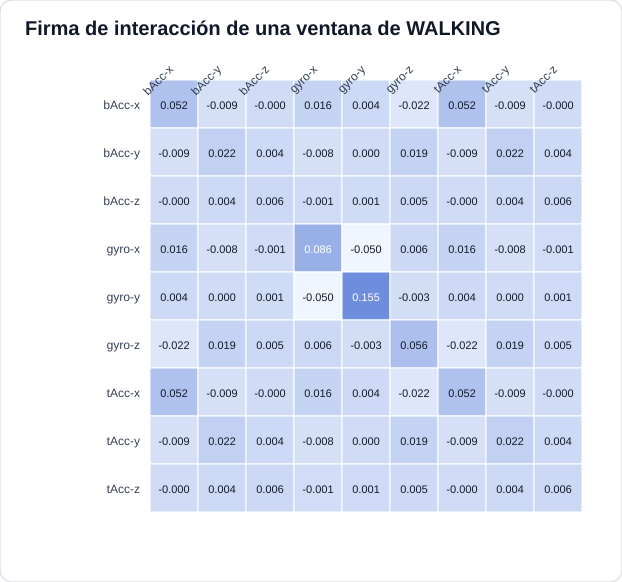

In [10]:
def heatmap_svg(
    matrix: torch.Tensor,
    row_labels: list[str],
    column_labels: list[str],
    title: str,
    integer_values: bool = False,
    cell_size: int = 48,
) -> str:
    matrix = matrix.detach().cpu().to(torch.float32)
    rows, columns = matrix.shape
    left, top = 150, 80
    width = left + columns * cell_size + 40
    height = top + rows * cell_size + 70
    minimum = float(matrix.min())
    maximum = float(matrix.max())
    span = maximum - minimum if maximum > minimum else 1.0

    cells = []
    for row in range(rows):
        for column in range(columns):
            value = float(matrix[row, column])
            normalized = (value - minimum) / span
            red = int(240 - 130 * normalized)
            green = int(246 - 105 * normalized)
            blue = int(255 - 35 * normalized)
            fill = f"rgb({red},{green},{blue})"
            text_fill = "#ffffff" if normalized > 0.58 else "#101828"
            shown = str(int(round(value))) if integer_values else f"{value:.3f}"
            x = left + column * cell_size
            y = top + row * cell_size
            cells.append(
                f'<rect x="{x}" y="{y}" width="{cell_size}" height="{cell_size}" '
                f'fill="{fill}" stroke="#ffffff"/>'
                f'<text x="{x + cell_size / 2}" y="{y + cell_size / 2 + 5}" '
                f'text-anchor="middle" font-size="11" font-family="Arial" '
                f'fill="{text_fill}">{shown}</text>'
            )

    row_text = []
    for row, label in enumerate(row_labels):
        y = top + row * cell_size + cell_size / 2 + 5
        row_text.append(
            f'<text x="{left - 10}" y="{y}" text-anchor="end" font-size="12" '
            f'font-family="Arial" fill="#344054">{html.escape(label)}</text>'
        )

    column_text = []
    for column, label in enumerate(column_labels):
        x = left + column * cell_size + cell_size / 2
        column_text.append(
            f'<text x="{x}" y="{top - 10}" text-anchor="end" font-size="12" '
            f'font-family="Arial" fill="#344054" '
            f'transform="rotate(-45 {x} {top - 10})">{html.escape(label)}</text>'
        )

    return (
        f'<svg viewBox="0 0 {width} {height}" xmlns="http://www.w3.org/2000/svg">'
        f'<rect width="{width}" height="{height}" rx="12" fill="#ffffff" '
        f'stroke="#d0d5dd"/><text x="25" y="35" font-size="20" '
        f'font-family="Arial" font-weight="700" fill="#101828">{html.escape(title)}</text>'
        f'{"".join(cells)}{"".join(row_text)}{"".join(column_text)}</svg>'
    )


short_channel_names = [
    "bAcc-x",
    "bAcc-y",
    "bAcc-z",
    "gyro-x",
    "gyro-y",
    "gyro-z",
    "tAcc-x",
    "tAcc-y",
    "tAcc-z",
]

display(
    SVG(
        heatmap_svg(
            G_test[walking_index],
            short_channel_names,
            short_channel_names,
            "Firma de interacción de una ventana de WALKING",
        )
    )
)



La matriz es simétrica porque $x_cx_d=x_dx_c$. Su diagonal mide energía;
los valores fuera de la diagonal muestran si dos canales tienden a cambiar
juntos dentro de la misma ventana.



## 7. Construir características y prototipos de actividad

Utilizaremos dos tipos de información por observación:

- las nueve medias $\mu_b$, que conservan orientación y postura;
- las 81 componentes de $G_b$, que describen variación e interacción.

Por tanto,

$$
F_b=[\mu_b,\operatorname{vec}(G_b)]\in\mathbb{R}^{90}.
$$

### De matrices a un vector de características

Para cada observación $b$ disponemos de:

- $\mu_b\in\mathbb{R}^{9}$: nueve medias, una por canal;
- $G_b\in\mathbb{R}^{9\times9}$: 81 relaciones entre pares de canales.

`flatten(start_dim=1)` conserva el eje de observaciones y convierte cada
matriz $9\times9$ en un vector de longitud $81$:

$$
(B,9,9)\longrightarrow(B,81).
$$

`torch.cat(..., dim=1)` coloca las nueve medias junto a esas 81 relaciones:

$$
9+81=90,
\qquad
F\in\mathbb{R}^{B\times90}.
$$

El índice $f=1,\ldots,90$ identificará una característica. Una fila $F_b$
resume una ventana completa; ya no conserva el eje temporal explícito.

### Estandarizar antes de comparar

Las 90 características pueden tener escalas distintas. Cada característica se
transforma utilizando la media y desviación estándar calculadas solamente con
entrenamiento:

$$
F^{(z)}_{bf}=\frac{F_{bf}-m_f}{s_f}.
$$

Los datos de prueba utilizan los mismos $m_f$ y $s_f$ de entrenamiento. Si se
calcularan estadísticas con prueba, introduciríamos fuga de información.

### Qué representa un prototipo

Para cada actividad $k$, promediamos las filas estandarizadas de entrenamiento
que tienen esa etiqueta:

$$
P_{kf}=\frac{1}{N_k}\sum_{b:y_b=k}F^{(z)}_{bf}.
$$

$P_k$ es una descripción promedio o prototipo de la actividad $k$. Como hay
seis actividades y 90 características:

$$
P\in\mathbb{R}^{6\times90}.
$$



In [11]:
F_train = torch.cat((mu_train, G_train.flatten(start_dim=1)), dim=1)
F_test = torch.cat((mu_test, G_test.flatten(start_dim=1)), dim=1)

print("F_train:", tuple(F_train.shape))
print("F_test: ", tuple(F_test.shape))
assert tuple(F_train.shape) == (720, 90)

# Estandarización calculada exclusivamente con entrenamiento.
feature_mean = F_train.mean(dim=0, keepdim=True)
feature_std = F_train.std(dim=0, keepdim=True).clamp_min(1e-6)

F_train_z = (F_train - feature_mean) / feature_std
F_test_z = (F_test - feature_mean) / feature_std

class_count = len(activity_names)
prototypes = torch.stack(
    [F_train_z[y_train == class_id].mean(dim=0) for class_id in range(class_count)]
)

print("Prototipos:", tuple(prototypes.shape), "= (actividad, característica)")
assert tuple(prototypes.shape) == (6, 90)



F_train: (720, 90)
F_test:  (360, 90)
Prototipos: (6, 90) = (actividad, característica)


## 8. Del prototipo más cercano a una transformación afín

En este paso, $F_b$ representa el vector de características ya estandarizado
que se compara con los prototipos construidos en el paso anterior.

Queremos asignar $F_b$ al prototipo $P_k$ más cercano:

$$
\lVert F_b-P_k\rVert^2
=\lVert F_b\rVert^2-2F_bP_k^{\mathsf T}+\lVert P_k\rVert^2.
$$

Para una observación fija, $\lVert F_b\rVert^2$ es igual para todas las
actividades. Minimizar la distancia equivale a maximizar

$$
S_{bk}=F_bP_k^{\mathsf T}-\frac{1}{2}\lVert P_k\rVert^2.
$$

En forma matricial:

$$
S=FP^{\mathsf T}+b,
\qquad
b_k=-\frac{1}{2}\sum_fP_{kf}^2.
$$

El producto matricial contrae el índice de característica $f$; sobreviven
observación $b$ y actividad $k$. El vector $b$ se replica sobre las
observaciones mediante broadcasting.

### Cómo leer los índices y las formas

- $b$ selecciona una observación de prueba;
- $k$ selecciona una de las seis actividades;
- $f$ recorre las 90 características;
- $F_{bf}$ es una característica de la observación;
- $P_{kf}$ es la misma característica en el prototipo de la actividad.

Una componente del puntaje se calcula como:

$$
S_{bk}=\sum_{f=1}^{90}F_{bf}P_{kf}+b_k.
$$

El producto matricial realiza simultáneamente esas sumas:

$$
F_{\text{test}}:(360,90),
\qquad
P^{\mathsf T}:(90,6),
$$

$$
(360,90)@(90,6)\longrightarrow(360,6).
$$

El eje de 90 características se contrae. Sobreviven 360 observaciones y seis
actividades. El vector `bias` tiene forma $(6,)$ y broadcasting agrega el
sesgo correspondiente a cada actividad en las 360 filas.

El resultado `scores[b, k]` indica qué tan compatible es la observación $b$
con el prototipo $k$. `argmax(dim=1)` selecciona el mayor de los seis puntajes
para cada observación:

$$
\widehat y_b=\arg\max_k S_{bk}.
$$

Se denomina transformación afín porque combina un producto matricial con una
suma de sesgo. La equivalencia con la distancia se verifica calculando también
las distancias cuadradas: ambos métodos deben producir la misma actividad.



In [12]:
bias = -0.5 * (prototypes * prototypes).sum(dim=1)
scores = F_test_z @ prototypes.T + bias
predicted = scores.argmax(dim=1)

print("bias:", tuple(bias.shape))
print("scores:", tuple(scores.shape))
print("predicted:", tuple(predicted.shape))

assert tuple(bias.shape) == (6,)
assert tuple(scores.shape) == (360, 6)
assert tuple(predicted.shape) == (360,)

# Verificación independiente mediante distancias cuadradas.
distances = ((F_test_z[:, None, :] - prototypes[None, :, :]) ** 2).sum(dim=2)
predicted_by_distance = distances.argmin(dim=1)
assert torch.equal(predicted, predicted_by_distance)



bias: (6,)
scores: (360, 6)
predicted: (360,)


## 9. Evaluar e interpretar

La matriz de confusión tendrá filas para la actividad real y columnas para la
actividad predicha. Una clasificación perfecta tendría todos sus valores en
la diagonal.

### Cómo leer la matriz de confusión

Sea $M\in\mathbb{N}^{6\times6}$. Su componente $M_{ij}$ cuenta cuántas
ventanas cuya actividad real era $i$ fueron clasificadas como $j$:

- las filas representan la actividad real;
- las columnas representan la actividad predicha;
- la diagonal $M_{ii}$ contiene los aciertos;
- los valores fuera de la diagonal contienen las confusiones.

El código convierte cada par `(real, predicha)` en una posición lineal:

$$
\text{posición}=6\times\text{real}+\text{predicha}.
$$

Por ejemplo, si la clase real es $2$ y la predicción es $4$, la posición es
$6(2)+4=16$. Después, `reshape(6, 6)` vuelve a organizar los 36 conteos como
filas y columnas.

La exactitud global es la proporción de aciertos sobre todas las ventanas:

$$
\text{accuracy}=\frac{\sum_i M_{ii}}{\sum_i\sum_j M_{ij}}.
$$

La exactitud de una actividad utiliza únicamente su fila:

$$
\text{accuracy}_i=\frac{M_{ii}}{\sum_jM_{ij}}.
$$

Por eso la exactitud global debe leerse junto con la matriz: un solo porcentaje
no muestra cuáles actividades se confunden.



Exactitud global: 76.67%
WALKING             : 41/60 = 68.33%
WALKING_UPSTAIRS    : 48/60 = 80.00%
WALKING_DOWNSTAIRS  : 34/60 = 56.67%
SITTING             : 44/60 = 73.33%
STANDING            : 51/60 = 85.00%
LAYING              : 58/60 = 96.67%


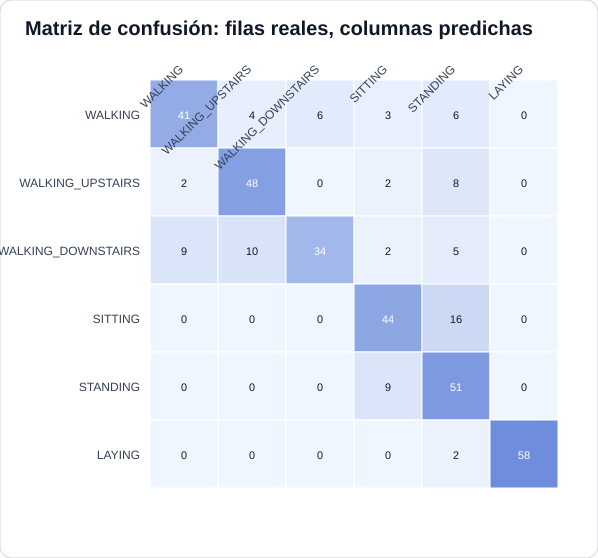

In [13]:
confusion = torch.bincount(
    class_count * y_test + predicted,
    minlength=class_count * class_count,
).reshape(class_count, class_count)

accuracy = (predicted == y_test).float().mean()
per_class_accuracy = confusion.diag() / confusion.sum(dim=1)

print(f"Exactitud global: {accuracy:.2%}")
for class_id, activity_name in enumerate(activity_names):
    print(
        f"{activity_name:20s}: {int(confusion[class_id, class_id]):2d}/"
        f"{int(confusion[class_id].sum()):2d} = "
        f"{float(per_class_accuracy[class_id]):.2%}"
    )

assert int(confusion.sum()) == len(y_test)

display(
    SVG(
        heatmap_svg(
            confusion,
            activity_names,
            activity_names,
            "Matriz de confusión: filas reales, columnas predichas",
            integer_values=True,
            cell_size=68,
        )
    )
)



### ¿Qué significan los resultados?

Con este subconjunto y esta solución determinista se clasifican correctamente
**276 de 360 observaciones: 76,67 %**.

- `LAYING` es la actividad más fácil: 58 de 60 ventanas correctas. La
  orientación del teléfono respecto de la gravedad aporta una señal clara.
- `SITTING` y `STANDING` se confunden entre sí. Ambas actividades tienen poca
  variación; sus diferencias dependen principalmente de la postura.
- Las tres actividades de marcha también se confunden. La firma resume una
  ventana completa y pierde el orden temporal fino que ayudaría a distinguir
  caminar, subir y bajar escaleras.

La exactitud no demuestra que cada operación sea correcta. La evidencia
matemática son las formas predichas y las igualdades verificadas:

$$
G_{\text{exterior}}=G_{\text{matmul}},
\qquad
\operatorname{diag}(G)=E,
\qquad
\arg\max S=\arg\min D.
$$



## 10. Clínica de error: código válido, eje equivocado

El siguiente candidato centra cada instante usando la media de los **canales**:

```python
wrong_center = X_train - X_train.mean(dim=2, keepdim=True)
```

Su forma sigue siendo $(B,T,C)$, por lo que `.shape` no detecta el error.
Sin embargo, nuestro contrato exigía centrar cada canal a lo largo del tiempo.

### Comparar la operación correcta con la incorrecta

La operación correcta calcula una media temporal para cada ventana y canal:

$$
\mu_{bc}=\frac{1}{T}\sum_tX_{btc}.
$$

En PyTorch corresponde a `mean(dim=1)`, porque el tiempo ocupa el eje $1$.
Después de restarla, cada canal debe tener media temporal cercana a cero.

El candidato incorrecto usa `mean(dim=2)`. Ese eje corresponde a los canales,
por lo que calcula otra cantidad:

$$
\alpha_{bt}=\frac{1}{C}\sum_cX_{btc}.
$$

La media $\alpha_{bt}$ se resta a todos los canales de un mismo instante. El
código es válido y conserva la forma $(B,T,C)$, pero responde una pregunta
diferente.

`keepdim=True` conserva el eje reducido con tamaño $1$ para permitir
broadcasting:

$$
(B,T,C)-(B,T,1)\longrightarrow(B,T,C).
$$

Este ejemplo muestra por qué comprobar solamente `.shape` es insuficiente.
También debemos comprobar el significado del eje reducido: en la solución
correcta, `Xc_train.mean(dim=1)` debe ser aproximadamente cero.



In [ ]:
wrong_center = X_train - X_train.mean(dim=2, keepdim=True)

wrong_channel_mean = wrong_center.mean(dim=2).abs().max()
wrong_time_mean = wrong_center.mean(dim=1).abs().max()

print("Media residual sobre canales:", float(wrong_channel_mean))
print("Media residual sobre tiempo:  ", float(wrong_time_mean))
print("La forma sigue siendo:", tuple(wrong_center.shape))

assert tuple(wrong_center.shape) == tuple(Xc_train.shape)
assert float(wrong_channel_mean) < 1e-5
assert float(wrong_time_mean) > 1e-3



El candidato responde otra pregunta: elimina el promedio entre sensores en
cada instante. Nuestra solución elimina el promedio temporal de cada sensor.
**Misma forma y ejecución exitosa no implican el mismo significado.**



## Síntesis

La cadena completa fue:

$$
(B,C,T)
\xrightarrow{\text{permute}}
(B,T,C)
\xrightarrow{\text{reducción + broadcasting}}
\widetilde X
\xrightarrow{\text{exterior + reducción}}
G
\xrightarrow{\text{reshape}}
F
\xrightarrow{\text{matmul + sesgo}}
S.
$$

El aprendizaje principal no es memorizar nombres de funciones. Es poder
anticipar qué eje se conserva, cuál se reduce o contrae y qué representa cada
componente del resultado.

En M08, PyTorch ajustará parámetros mediante gradientes. Antes de aprenderlos,
este taller establece qué relación matemática ejecutan esos parámetros.
